# 제 1 고지 - 미분 자동 계산

미분은 다양한 과학 기술 분야에 사용됨   
특히 딥러닝을 포함한 머신러닝의 여러 분야에서 중추적인 역할   
딥러닝 프레임워크는 말하자면 미분을 계산하기 위한 도구   
그래서 이 책의 주제도 자연스럽게 '미분'과 이어짐   
즉, 컴퓨터를 사용하여 미분을 계산하는 일이 주요 주제

지금부터 시작되는 제1고지는 총 10단계로 구성   
이 고지에서는 미분을 자동으로 계산하는 틀을 만듦   
'미분을 자동으로 계산한다'라는 말은 미분을 (사람이 아니라) 컴퓨터가 계산한다는 뜻   
정확히 말하면, 어떤 계산(함수)을 코드로 구현하면 그 계산의 미분을 컴퓨터가 자동으로 계산해주는 시스템을 가리킴   

이번 고지에서는 미분을 자동으로 계산하기 위해 '변수'와 '함수'를 표현하는 두 클래스 Variable과 Function을 만듦   
놀랍게도 이 두 클래스만으로 미분 자동 계산의 기반이 완성됨   
제1고지가 끝날 무렵에는 간단한 계산(함수)의 미분은 자동으로 계산할 수 있음   
그럼 DeZero의 첫 번째 단계를 시작

# 1. 상자로서의 변수

첫 번째 단계에서는 DeZero의 구성 요소인 '변수'를 만듦   
변수는 DeZero에서 가장 중요한 개념   
이번 단계에서는 변수가 어떤 기능을 하는지 이해하고, 그 기능에 맞게 코드로 구현함

## 1.1 변수란

본론으로 들어가서, 변수한 무엇인지?   
프로그래밍 입문서를 보면 변수는 대략 다음과 같은 이미지로 설명함   
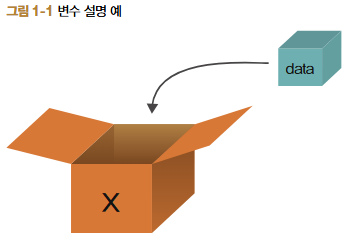   
- 그림과 같이 상자(box)에 데이터를 넣는 그림을 보여주며 이 '상자'가 바로 변수라고 설명함
- 변수를 상자에 비유한 설명은 변수의 성질을 (제법) 잘 보여줌
- 정리하면 다음과 같음
    - 상자와 데이터는 별개
    - 상자에는 데이터가 들어감(대입 혹은 할당함)
    - 상자 속을 들여다보면 데이터를 알 수 있음(참조함)

그럼 이 상자 그림에 맞게 DeZero 변수를 구현해봄

## 1.2 Variable 클래스 구현

변수는 영어로 variable   
그래서 DeZero에서 사용하는 변수라는 개념을 Variable이라는 이름의 클래스로 구현   
파이썬에서는 클래스 이름의 첫 글자를 보통 대문자로 함   
파이썬이 권장하는 코딩 규칙은 PEP8을 참고   

이제 Variable 클래스가 상자가 되도록 구현하기   
다음은 이 기능을 최소한의 코드로 작성한 것

In [4]:
class Variable:
    def __init__(self, data):
        self.data = data

- 보는 바와 같이 초기화 함수 __init__에 주어진 인수를 인스턴스 변수 data에 대입   

아주 간단한 코드지만, 이제 Variable 클래스를 상자로 사용할 수 있음   
싱제 데이터가 Variable의 data에 보관되기 때문   
예시를 하나 보면

In [5]:
import numpy as np

data = np.array(1.0)
x = Variable(data)
print(x.data)

1.0


- 이 예에서 상자에 넣는 데이터로는 '넘파이의 다차원 배열'을 사용
- 이때 x는 Varible 인스턴스이며, 실제 데이터는 x 안에 담겨 있음
- 즉, x는 데이터 자체가 아니라 데이터를 담은 상자가 됨   

머신러닝 시스템은 기본 데이터 구조로 '다차원 배열'을 사용   
그래서 DeZero의 Variable 클래스는 넘파이의 다차원 배열만 취급함   
넘파이의 다차원 배열 클래스는 numpy.ndarray이면 np.ndarray로 줄여 쓰곤 함   
넘파이 배열은 앞의 코드에서 볼 수 있듯 np.array 함수를 이용해 생성할 수 있음   
이 책에서는 앞으로 numpy.ndarray 인스턴스를 단순히 ndarray 인스턴스라고 부름   

이어서 앞 코드의 x에 새로운 데이터를 대입해보면

In [6]:
x.data = np.array(2.0)
print(x.data)

2.0


- 보는 바와 같이 x.data = ... 형태로 쓰면 새로운 데이터가 대입됨   

이제 Variable 클래스를 상자로 사용할 수 있게 됨   
이상이 1단계에서 구현하는 전부   
현재 Variable 클래스는 단 3줄의 코드밖에 없지만 이것을 기점으로 DeZero를 현대적인 프레임워크로 만들어갈 것

## 1.3 [보충] 넘파이의 다차원 배열

마지막으로 넘파이의 다차원 배열에 관해 간단히 보충   
다차원 배열은 숫자 등의 원소가 일정하게 모여 있는 데이터 구조   
다차원 배열에서 원소의 순서에는 방향이 있고, 이 방향을 **차원(demension)** 혹은 **축(axis)** 이라고 함   
다차원 배열의 예를 보면   
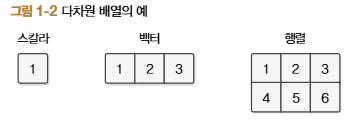   
- 그림에는 왼쪽부터 0차원 배열, 1차원 배열, 2차원 배열이 나오는데, 차례대로 **스칼라(scalar)**, **벡터(vector)**, **행렬(matrix)** 이라 함
- 스칼라는 단순히 하나의 수를 나타냄
- 벡터는 하나의 축을 따라 숫자가 늘어서 있고, 행렬은 축이 두 개   

> 다차원 배열을 **텐서(tensor)** 라고도 함   
> 위 그림은 왼쪽부터 0차원 텐서, 1차원 텐서, 2차원 텐서   

넘파이의 ndarray 인스턴스에는 ndim이라는 인스턴스 변수가 있음   
ndim은 'number of dimensions'의 약자로, 다차원 배열의 '차원 수'를 뜻함   
사용해보면

In [7]:
import numpy as np
x = np.array(1)
print(x.ndim)

x = np.array([1, 2, 3])
print(x.ndim)

x = np.array([[1, 2, 3], [4, 5, 6]])
print(x.ndim)

0
1
2


- 위 예시와 같이 인스턴스 변수인 ndim을 사용하여 배열이 몇 차원인지 확인할 수 있음   

> 벡터를 다룰 때는 '차원'이라는 말에 주의해야 함   
> 예를 들어 np.array([1, 2, 3])은 벡터인데, 세 개의 요소가 일렬로 늘어서 있기 때문에 '3차원 벡터'라고도 함   
> 이때 '벡터의 차원'은 벡터의 원소 수를 말함   
> 한편, '3차원 배열'이라고 할 때의 '배열의 차원'은 (원소가 아닌) 축이 3개라는 뜻   

여기까지와 같이 ndarray 인스턴스를 사용하면 스칼라, 벡터, 행렬, 더 높은 차원의 텐서를 만들 수 있음   
그러나 이 책에서는 당분간 스칼라만을 취급함   
나중에 37단계에 가면 벡터와 행렬도 다룰 수 있도록 DeZero를 확장할 것

# 2. 변수를 낳는 함수

앞 단계에서 Variable 클래스를 상자로 사용할 수 있게 했음   
하지만 지금 이대로는 그냥 상자일뿐   
단순한 상자를 마법의 상자로 바꾸는 장치가 필요한데, 그 열쇠는 바로 '함수'   
이번 단계에서는 함수에 대해 생각해봄

## 2.1 함수란

함수란 조금 딱딱하게 표현하면 '어떤 변수로부터 다른 변수로의 대응 관계를 정한 것'   
구체적인 예를 보면   
제곱을 계산하는 함수 $f(x) = x^2$ 이 있다고 할 때   
이때 $y = f(x)$ 라고 하면 변수 y와 x의 관계가 함수 f에 의해 결정됨   
즉, 함수 f에 의해 'y는 x의 제곱이다'라는 관계가 성립

이와 같이 변수 사이의 대응 관계를 정하는 역할을 함수가 맡게 되며,   
아래 그림은 그 의미를 시각적으로 표현한 것   
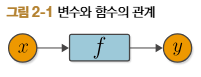   
- 그림은 변수 x와 y, 그리고 함수 f의 관계르 보여줌
- 이처럼 원과 사각형 모양의 노드들을 화살표로 연결해 계산 과정을 표현한 그림을 **계산 그래프(computational graph)** 라고 함
- 이 책에서는 변수를 원으로, 함수를 사각형으로 표시함   

> '그래프'라고 하면 막대그래프나 원그래프 같은 게 떠오를 수 있지만,   
> 컴퓨터 과학에서 그래프(graph)는 노드(node)(교점)과 에지(edge)(변, 간선)로 구성된 데이터 구조(혹은 그 구조를 나타낸 그림)를 말함   
> 위 그림에서 화살표는 '방향이 있는' 에지에 해당

## 2.2 Function 클래스 구현

그러면 위에 그림의 함수를 프로그래밍 관점에서 생각해보면   
구체적으로는, 앞서 구현한 Variable 인스턴스를 변수로 다룰 수 있는 함수를 Function 클래스로 구현   
여기서 주의할 점은 두 가지   
- Function 클래스는 Variable 인스턴스를 입력받아 Variable 인스턴스를 출력함
- Variable 인스턴스의 실제 데이터는 인스턴스 변수인 data에 있음   

이 두 가지에 유의하여 Function 클래스를 구현해보면

In [8]:
class Function:
    def __call__(self, input):
        x = input.data  # 데이터를 꺼냄
        y = x ** 2  # 실제 계산
        output = Variable(y)  # Variable 형태로 되돌림
        return output

- \_\_call__ 메서드의 인수 input은 Variable 인스턴스라고 가정함
- 따라서 실제 데이터는 input.data에 존재
- 데이터를 꺼낸 후 원하는 계산(여기서는 제곱)을 하고, 결과를 Variable이라는 '상자'에 담아 돌려줌   

> \_\_call__ 메서드는 파이썬의 특수 메서드   
> 이 메서드를 정의하면 f = Function() 형태로 함수의 인스턴스를 변수 f에 대입해두고, 나중에 f(...) 형태로 \_\_call__ 메서드를 호출할 수 있음   

## 2.3 Function 클래스 이용

Function 클래스를 실제로 사용하기   
Variable 인스턴스인 x를 Function 인스턴스인 f에 입력해보면

In [9]:
x = Variable(np.array(10))
f = Function()
y = f(x)

print(type(y))  # type() 함수는 객체의 클래스를 알려줌
print(y.data)

<class '__main__.Variable'>
100


- 이와 같이 Variable과 Function을 연계할 수 있음
- 실행 결과를 보면 y의 클래스는 Variable이며, 데이터는 y.data에 잘 저장되어 있음을 알 수 있음   

그런데 방금 구현한 Function 클래스는 용도가 '입력값의 제곱'으로 고정된 함수   
따라서 Square라는 명확한 이름이 더 어울림   
앞으로 Sin, Exp 등 다양한 함수가 필요하다는 점을 고려하면 Function 클래스는 기반 클래스로 두고 DeZero의 모든 함수가 공통적으로 제공하는 기능만 담아두는 것이 좋음   
그래서 앞으로 모든 DeZero 함수는 다음의 두 사항을 충족하도록 구현함   
- Function 클래스는 기반 클래스로서, 모든 함수에 공통되는 기능을 구현함
- 구체적인 함수는 Function 클래스를 상속한 클래스에서 구현함   

이를 위해 Function 클래스를 수정하면

In [10]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)  # 구체적인 계산은 forward 메서드에서 함
        output = Variable(y)
        return output

    def forward(self, x):
        raise NotImplementedError()

- \_\_call__을 살짝 수정하고 forward라는 메서드를 추가
- \_\_call__ 메서드는 'Variable에서 데이터 찾기'와 '계산 결과를 Variable에 포장하기'라는 두 가지 일을 함
- 그리고 그 사이의 구체적인 계산은 forward 메서드를 호출하여 수행
- 마지막으로 forward 메서드의 구체적인 로직은 하위 클래스에서 구현   

> Function 클래스의 forward 메서드는 예외를 발생시킴   
> 이렇게 해두면 Function 클래스의 forward 메서드를 직접 호출한 사람에게 '이 메서드는 상속하여 구현해야 한다'는 사실을 알려줄 수 있음   

이어서 Function 클래스를 상속하여 입력값을 제곱하는 클래스를 구현함   
클래스 이름은 Square라고 지음

In [11]:
class Square(Function):
    def forward(self, x):
        return x ** 2

- Square 클래스는 Function 클래스를 상속하기 때문에 \_\_call__ 메서드는 그대로 계승됨
- 따라서 forward 메서드에 구체적인 계산 로직을 작성해 넣는 것만으로 구현은 끝   

실제로 잘 동작하는지 살펴보면

In [12]:
x = Variable(np.array(10))
f = Square()
y = f(x)
print(type(y))
print(y.data)

<class '__main__.Variable'>
100


- 보다시피 이전과 같은 결과를 얻음   

이것으로 2단계로 끝   
Variable과 Function 클래스의 기초가 완성됨   

> 한동안 Function의 입력과 출력은 '하나의 변수'로 한정   
> DeZero가 여러 변수를 다룰 수 있도록 확장하는 작업은 11단계에서 진행

# 3. 함수 연결

지금까지 DeZero의 '변수'와 '함수'를 구현함   
그리고 2단계에서는 Square라는 제곱 계산용 함수 클래스를 구현함   
이번 단계에서는 또 다른 함수를 구현하고 여러 함수를 조합해 계산할 수 있도록 함

## 3.1 Exp 함수 구현

우선 DeZero에 새로운 함수를 하나 구현   
$y = e^x$ 이라는 계산을 하는 함수   
여기서 e는 자연로그의 밑(base of the natural logarithm)으로 구체적인 값은 2.718...(오일러의 수(Enler's number) 혹은 네이피어 상수(Napier's constant)라고도 함)   

In [13]:
class Exp(Function):
    def forward(self, x):
        return np.exp(x)

- Square 클래스와 마찬가지로 Function 클래스를 상속한 다음 forward 메서드에서 원하는 계산을 구현
- Square 클래스와의 차이는 forward 메서드의 내용이 x ** 2에서 np.exp(x)로 바뀐 점

## 3.2 함수 연결

Function 클래스의 \_\_call__ 메서드는 입력과 출력이 모두 Variable 인스턴스이므로 자연스럽게 DeZero 함수들을 연이어 사용할 수 있음   
$y = (e^{x^2})^2$ 이라는 계산을 예로 생각해보면

In [14]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)
print(y.data)

1.648721270700128


- 3개의 함수 A, B, C를 연이어 적용했음
- 여기서 중요한 점은 중간에 등장하는 4개의 변수 x, a, b, y가 모두 Variable 인스턴스라는 것
- Function 클래스의 \_\_call__ 메서드의 입출력이 Variable 인스턴스로 통일되어 있는 덕분에 이와 같이 여러 함수를 연속하여 적용할 수 있는 것   

위 코드의 계산은 다음 그림과 같이 함수와 변수가 교대로 늘어선 계산 그래프로 표현할 수 있음   
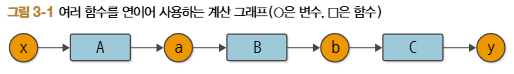   

> 그림과 같이 여러 함수를 순서대로 적용하여 만들어진 변환 전체를 하나의 큰 함수로 볼 수도 있음   
> 이처럼 여러 함수로 구성된 함수를 **합성 함수(composite function)** 라고 함   
> 합성 함수를 구성하는 각 함수의 계산은 간단하더라도, 연속으로 적용하면 더 복잡한 계산도 해낼 수 있는 것   

그런데 일련의 계산을 '계산 그래프'로 보여준 이유는   
계산 그래프를 이용하면 각 변수에 대한 미분을 효율적으로 계산할 수 있기 때문(정확하게는 그럴 준비가 됨)   
그리고 변수별 미분을 계산하는 알고리즘이 바로 역전파   
다음 단계부터는 역전파를 구현할 수 있도록 DeZero를 확장함

# 4. 수치 미분

지금까지 Variable 클래스와 Function 클래스를 구현함   
이 클래스들을 구현한 이유는 미분을 자동으로 계산하기 위해서   
본격적인 구현에 앞서 이번 단계에서는 미분이 무엇인지 복습하고 수치 미분이라는 간단한 방법으로 미분을 계산해볼 것   
그런 다음 5단계에서 수치 미분을 대신하는 더 효율적인 알고리즘(역전파)을 구현할 계획   

> 머신러닝 외에도 많은 분야에서 미분을 활용함   
> 유체 역학, 금융 공학, 기상 시뮬레이션, 엔지니어링 설계 최적화 등   
> 이런 다양한 분야에서 자동 미분 계산 기능이 실제로 사용되고 있음

## 4.1 미분이란

미분이란 간단히 말하면 '변화율'을 뜻함   
예컨대 물체의 시간에 따른 위치 변화율(위치의 미분)은 속도가 됨   
시간에 대한 속도 변화율(속도의 미분)은 가속도에 해당   
이와 같이 미분은 변화율을 나타냄   
정확한 정의는 '극한으로 짧은 시간(순간)'에서의 변화량   
수식으로 표현하면 f(x)라는 함수가 있을 때 미분은 다음 식으로 정의됨   
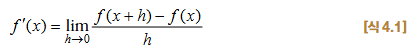   
- 식의 $\lim\limits_{h \to 0}$ 은 극한을 나타내며, h가 한없이 0에 근접한다는 뜻
- 여기서 식의 $\frac{f(x+h)-f(x)}{h}$는 아래 그림과 같이 두 점을 지나는 직선의 기울기   

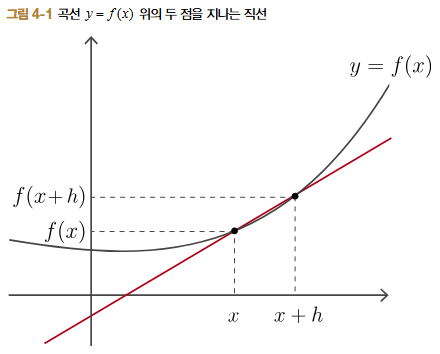   
- 그림에서 보듯 x와 x+h라는 두 점에서 함수 f(x)의 변화 비율은 $\frac{f(x+h)-f(x)}{h}$
- 여기서 폭 h를 한없이 0에 가깝게 줄여 x의 변화 비율을 구하면 그 값이 바로 y = f(x)의 미분
- 또한 y = f(x)가 어떤 구간에서 미분 가능하다면 위에 식은 해당 구간의 '모든 x'에서 성립함
- 따라서 위 식의 f'(x)도 함수이며, f(x)의 **도함수** 라고 함

## 4.2 수치 미분 구현

그럼 미분을 정의한 위 식에 따라 미분을 계산하는 코드를 구현   
그런데 컴퓨터는 극한을 취급할 수 없으니 h를 극한과 비슷한 값으로 대체   
예를 들어 h = 0.0001(= 1e-4)과 같은 매우 작은 값을 이용하여 식을 계산   
이런 미세한 차이를 이용하여 함수의 변화량을 구하는 방법을 **수치 미분(numerical differentiation)** 이라고 함   

수치 미분은 작은 값을 사용하여 '진정한 미분'을 근사함   
따라서 값에 어쩔 수 없이 오차가 포함되는데, 이 근사 오차를 줄이는 방법으로는 '중앙차분(centered difference)'이라는 것이 있음   

중앙차분은 f(x)와 f(x+h)의 차이를 구하는 대신 f(x-h)와 f(x+h)의 차이를 구함   
그림으로 나타내면 아래 그림의 파란 선에 해당   
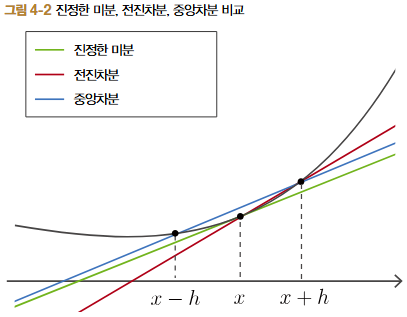   
- 그림에서 보듯 x와 x+h 지점에서의 기울기를 구하는 방법을 '전진차분(forward difference)'이라 하고, x-h와 x+h에서의 기울기를 구하는 방법을 '중앙차분'이라 하는데,
- 중앙차분 쪽이 상대적으로 오차가 작음
- 책에 증명까지는 싣지 않았지만 직관적으로는 그림에서 직선들의 기울기를 비교해보면 알 수 있음
- 중앙차분에서 직선의 기울기는 $\frac{f(x+h)-f(x-h)}{2h}$ (분모가 2h인 점에 주의)   

> 전진차분보다 중앙차분이 진정한 미분값에 가깝다는 사실은 테일러 급수(Taylor series)를 이용해 증명할 수 있음   

그러면 중앙차분을 이용하여 수치 미분을 계산하는 함수를 numerical_diff(f, x, eps=1e-4)라는 이름으로 구현함   
첫 번째 인수 f는 미분의 대상이 되는 함수이며, 앞에서 구현한 Function의 인스턴스   
두 번째 인수 x는 미분을 계산하는 변수로, Variable 인스턴스   
마지막의 eps는 작은 값을 나타내며, 기본값은 1e-4   
수치 미분을 구현해보면

In [15]:
def numerical_diff(f, x, eps=1e-4):
    x0 = Variable(x.data - eps)
    x1 = Variable(x.data + eps)
    y0 = f(x0)
    y1 = f(x1)
    return (y1.data - y0.data) / (2 * eps)

- 실제 데이터는 Variable의 인스턴스 변수인 data에 들어 있다는 것만 주의하면 특별히 조심할 점은 없음   

그러면 3단계에서 구현한 Square 클래스를 대상으로 미분해보면

In [16]:
f = Square()
x = Variable(np.array(2.0))
dy = numerical_diff(f, x)
print(dy)

4.000000000004


- 이렇게 함수 $y = x^2$에서 $x = 2.0$일 때 수치 미분한 결과를 구함
- 오차가 없었다면 4.0이 나왔어야 하니, 이 결과는 거의 올바른 값이라고 할 수 있음   

> 미분을 해석적으로 계산할 수도 있음   
> 해석적으로 계산한다고 함은 수식 변형만으로 답을 유도한다는 뜻   
> 앞의 예에서는 미분 공식으로부터 $y = x^2$일 때 $\frac{dy}{dx} = 2x$가 됨($\frac{dy}{dx}$는 y의 x에 대한 미분을 뜻하는 기호)
> 따라서 x =2.0에서의 미분값은 4.0   
> 이 4.0이리는 값은 오차를 포함하지 않는 정확한 값   
> 앞의 수치 미분 결과는 비록 정획하지는 않지만 오차가 매우 작음을 알 수 있음

## 4.3 합성 함수의 미분

지금까지는 $y = x^2$이라는 간순한 함수를 다뤘음   
이어서 합성 함수를 미분   
$y = (e^{x^2})^2$이라는 계산에 대한 미분 $\frac{dy}{dx}$를 계산할 것

In [17]:
def f(x):
    A = Square()
    B = Exp()
    C = Square()
    return C(B(A(x)))

x = Variable(np.array(0.5))
dy = numerical_diff(f, x)
print(dy)

3.2974426293330694


- 이 코드는 일련의 계산을 f라는 함수로 정리
- 파이썬에서는 함수도 객체이기 때문에 다른 함수에 인수로 전달할 수 있음
- 실제로 앞의 코드에서는 numerical_diff 함수에 함수 f를 전달했음
- 실행 결과를 보면 미분한 값이 3.297...   
- x를 0.5에서 작은 값만큼 변화시키면 y는 작은 값의 3.297... 배만큼 변한다는 의미

이상에서 미분을 '자동으로' 계산하는 데 성공함   
원하는 계산을 파이썬 코드로 표현한 다음(앞의 에에서는 함수 f로 정의) 미분해달라고 프로그램에 요구했음   
이 방식대로 하면 아무리 복잡하게 조합된 함수라도 미분을 자동으로 계산할 수 있음   
이제부터는 함수의 종류를 늘려가면서 어떠한 계산도 (미분 가능한 함수라면) 미분할 수 있음   
그러나 안타깝게도 수치 미분에는 문제가 있음

## 4.4 수치 미분의 문제점

수치 미분의 결과에는 오차가 포함되어 있음   
대부분의 경우 오차는 매우 작지만 어떤 계산이냐에 따라 커질 수도 있음   

> 수치 미분의 결과에 오차가 포함되기 쉬운 이유는 주로 '자릿수 누락' 때문   
> 중앙치분 등 '차이'를 구하는 계산은 주로 크기가 비슷한 값들을 다루므로 계산 결과에서 자릿수 누락이 생겨 유효 지릿수가 줄어들 수 있음   
> 예를 들어 유효 자릿수가 4일 때 1.234 - 1.233이라는 계산(비슷한 값끼리의 뺄셈)을 생각해보면,   
> 계산 결과는 0.001이 되어 유효 지릿수가 1로 줄어듦   
> 원래는 1.234... - 1.233... = 0.001434... 같은 결과였을지도 모르는데, 자릿수 누락 때문에 0.001이 됐다고 볼 수 있음   
> 이와 같은 원리 때문에 수치 미분을 이용하면 지릿수 누락이 발생하여 오차가 포함되기 쉬움   

수치 미분의 더 심각한 문제는 계산량이 많다는 점   
변수가 여러 개인 계산을 미분할 경우 변수 각각을 미분해야 하기 때문   
신경망에서는 매개변수를 수백만 개 이상 사용하는 건 일도 아니므로 이 모두를 수치 미분으로 구하는 것은 현실적이지 않음   
그래서 등장한 것이 바로 역전파   
다음 단계에서 역전파를 소개함   

덧붙여서, 수치 미분은 구현하기 쉽고 거의 정확한 값을 얻을 수 있음   
이에 비해 역전파는 복잡한 알고리즘이라서 구현하면서 버그가 섞여 들어가기 쉬움   
그래서 역전파를 정확하게 구현했는지 확인하기 위해 수치 미분의 결과를 이용하곤 함   
이를 **기울기 확인(gradient checking)** 이라고 하는데, 단순히 수치 미분 결과와 역전파의 결과를 비교하는 것   
기울기 확인은 10단계에서 구현

# 5. 역전파 이론

수치 미분을 이용해 미분을 계산할 수 있게 되었지만 수치 미분은 계산 비용과 정확도 면에서 문제가 있음   
지금이 바로 역전파(backpropagation)(오차역전파법)가 등장할 시점   
역전파를 이용하면 미분을 효율적으로 계산할 수 있고 결괏값의 오차도 더 작음   
이번 단계에서는 아직 역전파 구현까지는 들어가지 않고 이론 설명에 집중(구현은 다음 단계에서)

## 5.1 연쇄 법칙

역전파를 이해하는 열쇠는 **연쇄 법칙(chain rule)**   
chain은 '사슬'이라는 뜻으로, 여러 함수를 사슬처럼 연결하여 사용하는 모습을 빗댄 것   
연쇄 법칙에 따르면 함성 함수(여러 함수가 연결된 함수)의 미분은 구성 함수 각각을 미분한 후 곱한 것과 같음

구체적인 예를 하나 들어보면   
y=F(x)라는 함수가 있다고 할 때   
이 함수는 a=A(x), b=B(a), y=C(b)라는 세 함수로 구성되어 있음   
계산 그래프로 그리면   
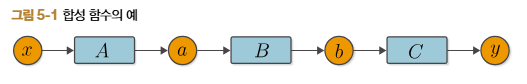   
이때 x에 대한 y의 미분은   
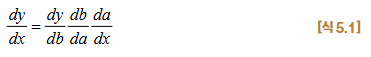   
- 식에서 알 수 있듯이 x에 대한 y의 미분은 구성 함수 각각의 미분값을 모두 곱한 값과 같음
- 즉, 합성 함수의 미분은 각 함수의 국소적인 미분들로 분해할 수 있음
- 이것이 연쇄법칙
- 또한 위 식 앞에 다음과 같이 $\frac{dy}{dy}$를 명시할 수도 있음   

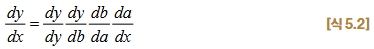
- $\frac{dy}{dy}$는 '자신에 대한 미분이라서 항상 1
- 따라서 생략하는 것이 보통이지만 이 책에서는 역전파를 구현할 때를 대비하여 포함시키도록 함   

> $\frac{dy}{dy}$는 y의 y에 대한 미분   
> 이때 y가 작은 값만큼 변하면 자기 자신인 y도 당연히 같은 크기만큼 변함   
> 따라서 변화율은 어떤 함수의 경우에도 항상 1

## 5.2 역전파 원리 도출

이제 위 식를 차분히 살펴봄   
위 식은 합성 함수의 미분은 구성 함수들의 미분의 곱으로 분해할 수 있음을 뜻함   
'곱하는 순서'까지 말해주지는 않지만 사실 어떤 순서로 곱해도 상관없음   
그러니 아래 식과 같이 출력에서 입력 방향으로(즉, 역방향으로) 순서대로 계산해보면   
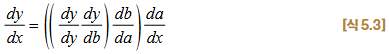   
- 이 식과 같이 출력에서 입력 방향으로, 즉 보통의 계산과는 반대 방향으로 미분을 계산함   
- 이때 이 식의 계산 흐름은 다음과 같음   

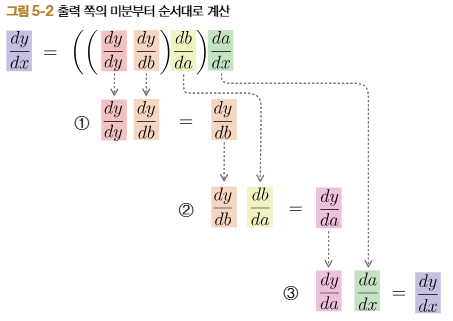   
- 그림처럼 출력 y에서 입력 x 방향으로 곱하면서 순서대로 미분하면 최종적으로 $\frac{dy}{dx}$가 구해짐
- 계산 그래프로는 다음과 같음   

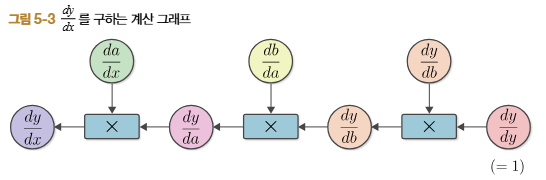   
- 그림의 계산 그래프를 잘 관찰해보면
- 우선 $\frac{dy}{dy}$(=1)에서 시작하여 $\frac{dy}{db}$와 곱함
- 여기서 $\frac{dy}{db}$는 함수 y = C(b)의 미분
- 따라서 함수 C의 도함수를 C'로 나타내면  $\frac{dy}{db} = C'(b)$라고 쓸 수 있음
- 마찬가지로 $\frac{db}{da} = B'(a)$이고 $\frac{da}{dx} = A'(x)$
- 이에 따라 위 그림의 계산 그래프는 다음과 같이 단순화할 수 있음   

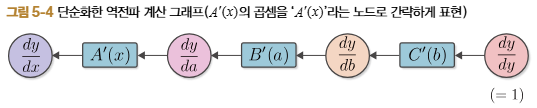   
- 그림과 같이 도함수의 곱을 함수 노드 하나로 그릴 수 있음
- 이제 미분값이 전파되는 흐름이 명확해짐
- 그림를 보면 'y의 각 변수에 대한 미분값'이, 즉 변수 y, b, a, x에 대한 미분값이 오른쪽에서 왼쪽으로 전파되는 것을 알 수 있음
- 이것이 역전파
- 여기서 중요한 점은 전파되는 데이터는 모두 'y의 미분값'이라는 것
- 구체적으로는 $\frac{dy}{dy}$, $\frac{dy}{db}$, $\frac{dy}{da}$, $\frac{dy}{dx}$처럼 모두 'y의 OO에 대한 미분값'이 전파되고 있음   

> 위 식(5-3)과 같이 계산 순서를 출력에서 입력 방항으로 정한 이유는 y의 미분값을 전파하기 위해서   
> 즉, y를 '중요 요소'로 대우하기 때문   
> 만약 입력에서 출력 방향으로 계산했다면 중요 요소는 입력인 x가 됨   
> 이 경우 전파되는 값은 $\frac{dx}{dx}$ -> $\frac{da}{dx}$ -> $\frac{db}{dx}$ -> $\frac{dy}{dx}$가 되어 x에 대한 미분을 전파하게 됨   

머신러닝은 주로 대량의 매개변수를 입력받아서 마지막에 **손실 함수(loss function)** 를 거쳐 출력을 내는 형태로 진행됨   
손실 함수의 출력은 (많은 경우) 단일한 스칼라값이며, 이 값이 '중요 요소'   
즉, 손실 함수의 각 매개변수에 대한 미분을 계산해야 함   
이런 경우 미분값을 출력에서 입력 방향으로 전파하면 한 번의 전파만으로 모든 매개변수에 대한 미분을 계산할 수 있음   
이처럼 계산이 효율적으로 이뤄지기 때문에 미분을 반대 방향으로 전파하는 방식(역전파)을 이용하는 것

## 5.3 계산 그래프로 살펴보기

다음과 같이 통상적인 계산인 순전파 계산 그래프와 미분을 계산하는 역전파 계산 그래프를 위아래로 나란히 놓고 보면   
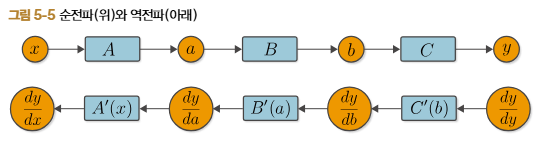   
- 이렇게 비교하면 순전파와 역전파의 관계가 명확히 보임
- 예를 들어 순전파 시의 변수 a는 역전파 시의 미분 $\frac{dy}{da}$에 대응
- 마찬가지로 b와 $\frac{dy}{db}$가 대응하고 x와 $\frac{dy}{dx}$가 대응
- 또한 함수에도 대응 관계가 보임
    - 함수 B는 역전파의 B'(a)에 대응하고 A는 A'(x)에 대응하는 식
    - 이렇게 변수는 '통상값'과 '미분값'이 존재하고, 함수는 '통상 계산(순전파)'과 '미분값을 구하기 위한 계산(역전파)'이 존재하는 것으로 생각할 수 있음
    - 이를 통해 역전파를 어떻게 구현할지 짐작해볼 수 있을 것
- 마지막으로 그림의 함수 노드 C'(b)에 주목해보면
- y = C(b)라는 계산의 미분이지만, 여기서 주의할 점은 C'(b)를 계산하려면 b값이 필요하다는 사실
- 마찬가지로 B'(a)를 구하려면 입력 a의 값이 필요
- 역전파 시에는 순전파 시 이용한 데이터가 필요하다는 것
- 따라서 역전파를 구현하려면 먼저 순전파를 하고, 이때 각 함수가 입력 변수(앞의 에에서는 x, a, b)의 값을 기억해두지 않으면 안 됨
- 그런 다음에야 각 함수의 역전파를 계산할 수 있음   

이상이 역전파의 이론 설명
다행히 역전파는 이 책에서 가장 어려운 내용에 속함   
그리고 아직 잘 이해되지 않는 부분도 실제로 코드를 실행해보면 이해될 것   
다음 단계에서는 역전파를 구현하고 실제로 돌려보며 검증함

# 6. 수동 역전파

이전 단계에서 역전파의 구동 원리를 살펴봄   
이번 단계에서는 Variable과 Function 클래스를 확장하여 역전파를 이용한 미분을 구현함

## 6.1 Variable 클래스 추가 구현

역전파에 대응하는 Variable 클래스를 구현함   
그러기 위해 통상값(data)과 더불어 그에 대응하는 미분값(grad)도 저장하도록 확장함   

In [18]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None

- 이와 같이 새로 grad라는 인스턴스 변수를 추가
- 인스턴스 변수인 data와 grad는 모두 넘파이의 다차원 배열(ndarray)이라고 가정
- 또한 grad는 None으로 초기화해둔 다음, 나중에 실제로 역전파를 하면 미분값을 계산하여 대입   

> 벡터나 행렬 등 다변수에 대한 미분은 기울기(gradient)라고 함   
> Variable 클래스에 새로 추가한 grad 변수의 이름은 gradient를 줄인 것   

## 6.2 Function 클래스 추가 구현

Function 클래스를 알아볼 차례   
이전 단계까지의 Function 클래스는 일반적인 계산을 하는 순전파(forward 메서드) 기능만 지원하는 상태   
이외에 다음 두 기능을 추가
- 미분을 계산하는 역전파(backward 메서드)
- forward 메서드 호출 시 건네받은 Variable 인스턴스 유지   

이 두 기능을 구현하면

In [19]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(y)
        self.input = input  # 입력 변수를 기억(보관)
        return output

    def forward(self, x):
        raise NotImplementedError()

    def backward(self, x):
        raise NotImplementedError()

- 코드에서 보듯 \_\_call__ 메서드에서 입력된 input을 인스턴스 변수인 self.input에 저장함
- 이렇게 해서 나중에 backward 메서드에서 함수(Function)에 입력한 변수(Variable 인스턴스)가 필요할 때 self.input에서 가져와 사용할 수 있음

## 6.3 Square와 Exp 클래스 추가 구현

이어서 Function을 상속한 구체적인 함수에서 역전파(backward)를 구현해봄   
첫 번째 대상은 제곱을 계산하는 Square 클래스   
$y = x^2$의 미분은 $\frac{dy}{dx} = 2x$가 되기 때문에 다음처럼 구현할 수 있음

In [29]:
class Square(Function):
    def forward(self, x):
        y = x ** 2
        return y

    def backward(self, gy):
        x = self.input.data
        gx = 2 * x * gy
        return gx

- 이와 같이 역전파를 담당하는 backward 메서드를 추가
- 이 메서드의 인수 gy는 ndarray 인스턴스이며, 출력 쪽에서 전해지는 미분값을 전달하는 역할
- 그리고 인수로 전달된 미분에 '$y = x^2$의 미분'을 곱한 값이 backward의 결과
- 역전파에서는 이 결괏값을 입력 쪽에 더 가까운 다음 함수로 전파해나갈 것   

이어서 $y = e^x$ 계산을 할 Exp 클래스   
이 계산의 미분은 $\frac{dy}{dx} = e^x$이기 때문에 다음과 같음

In [30]:
class Exp(Function):
    def forward(self, x):
        y = np.exp(x)
        return y

    def backward(self, gy):
        x = self.input.data
        gx = np.exp(x) * gy
        return gx

## 6.4 역전파 구현

이상으로 준비 작업이 끝   
이번 절에서는 아래 그림에 해다하는 계산의 미분을 역전파로 계산해봄   
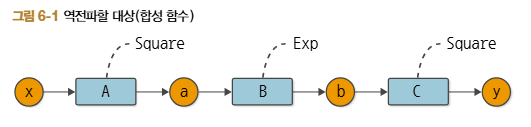   
먼저 이 그림을 순전파하는 코드부터 보면

In [22]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
c = C(b)

이어서 역전파로 y를 미분해보면   
순전파 때와는 반대 순서로 각 함수의 backward 멕서드를 호출하면 됨   
아래 그림은 이떄 이루어지는 역전파를 계산 그래프로 그린 모습   
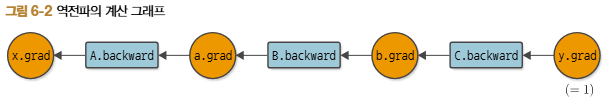   
- 그림을 보면 어떤 순서로 어느 함수의 backward 메서드를 호출하면 되는지 알 수 있음
- 또한 backward 메서드의 결과를 어느 변수의 grad로 설정하면 되는지도 알 수 있음   

이 그림의 계산 그래프를 코드로 옮기면

In [23]:
y.grad = np.array(1.0)
b.grad = C.backward(y.grad)
a.grad = B.backward(b.grad)
x.grad = A.backward(a.grad)
print(x.grad)

3.297442541400256


- 역전파는 $\frac{dy}{dy} = 1$에서 시작
- 따라서 출력 y의 미분값을 np.array(1.0)로 설정
- 그런 다음 C -> B -> A 순으로 backward 메서드를 호출하기만 하면 됨
- 이것으로 각 변수의 미분값이 구해짐
- 위 코드를 실행하면 x.grad의 값이 3.297442541400256이라고 나옴
- 이 값이 y의 x에 대한 미분 결과
- 4단계에서 수치 미분으로 구한 값이 3.2974426293330694였으니 두 결과가 거의 같음 - 역전파를 제대로 구현한 것(더 정확하게는, 올바르게 구현했을 가능성이 큼)   

이상이 역전파 구현   
제대로 동작하지만 역전파 순서(C -> B -> A)에 맞춰 호출하는 코드를 일일이 작성해 넣는 건 불편함   
그래서 다음 단계에서는 이 작업을 자동화함

# 7. 역전파 자동화

이전 단계에서 역전파를 동작시키는 데 성공함   
그러나 역전파 계산 코드를 수동으로 조합해야 했음   
새로운 계산을 할 때마다 역전파 코드를 직접 작성해야 한다는 뜻   
아래 그림처럼 계산 그래프가 여러 개라면 각각의 계산에 맞게 역전파 코드를 수동으로 따로따로 작성해야 함   
그러다 보면 실수가 생길 수 있고, 지루할 것   
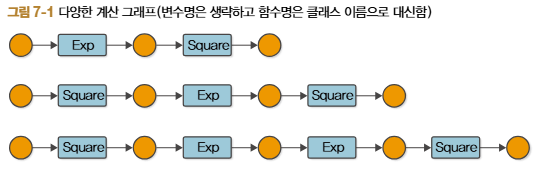   

그래서 이제부터 역전파를 자동화하려 함   
더 정확히 말하면, 일반적인 계산(순전파)을 한 번만 해주면 어떤 계산이라도 상관없이 역전파가 자동으로 이루어지는 구조를 만들 것   
지금부터가 바로 Define-by-Run의 핵심을 건드리는 내용   

> Define-by-Run이란 딥러닝에서 수행하는 계산들을 계산 시점에 '연결'하는 방식으로, '동적 계산 그래프'라고도 함   
> Define-by-Run의 개념과 장점은 제 2고지 마지막의 '칼럼: Define-by-Run'에서 자세히 설명   

그런데 위 그림의 계산 그래프들은 모두 일직선으로 늘어선 계산   
따라서 함수의 순서를 리스트 형태로 저장해두면 나중에 거꾸로 추적하는 식으로 역전파를 자동화할 수 있음   
그러나 분기가 있는 계산 그래프나 같은 변수가 여러 번 사용되는 복잡한 계산 그래프는 단순히 리스트로 저장하는 식으로는 풀 수 없음   
여기서 목표는 아무리 복잡한 계산 그래프라 하더라도 역전파를 자동으로 할 수 있는 구조를 마련하는 것   

> 사실 리스트 데이터 구조를 응용하면 수행한 계산을 리스트에 추가해 나가는 것만으로 어떠한 계산 그래프의 역전파도 제대로 해낼 수 있음   
> 이 데이터 구조를 웬거트 리스트(Wengert List)(혹은 테이프(tape))라고 함   
> 이 책에서는 웬거트 리스트에 대한 설명은 하지 않음   

## 7.1 역전파 자동화의 시작

역전파 자동화로 가는 길은 변수와 함수의 '관계'를 이해하는 데서 출발   
우선 함수 관점에서 '함수는 변수를 어떻게 바라볼까'를 생각해보면   
함수 입장에서 변수는 '입력'과 '출력'에 쓰임   
즉, 아래 그림의 왼쪽과 같이 함수에게 변수는 '입력 변수(input)'와 '출력 변수(output)'로서 존재함(그림의 점선은 참조(reference)를 뜻함)   
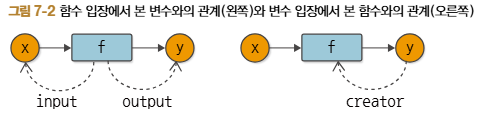   

변수 관점에서 함수는 어떤 존재인지?   
여기서 눈여겨볼 점은 변수는 함수에 의해 '만들어진다'라는 것   
즉, 변수에게 있어 함수는 '창조자(creator)' 혹은 '부모'   
창조자인 함수가 존재하지 않는 변수는 함수 이외의 존재, 예컨대 사용자에 의해 만들어진 변수로 간주됨   

일단 위 그림과 같은 함수와 변수의 관계를 DeZero 코드에 녹여보면   
여기에서는 일반적인 계산(순전파)이 이루어지는 시점에 '관계'를 맺어주도록(즉, 함수와 변수를 연결 짓도록) 만들 예정   
이를 위해 우선 Variable 클래스에 다음 코드를 추가함

In [27]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

- creator라는 인스턴스 변수를 추가
- 그리고 creator를 설정할 수 있도록 set_creator 메서드도 추가   

이어서 Function 클래스에 다음 코드를 추가

In [28]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(y)
        output.set_creator(self)  # 출력 변수에 창조자를 설정
        self.input = input
        self.output = output  # 출력도 저장
        return output

    def forward(self, x):
        raise NotImplementedError()

    def backward(self, x):
        raise NotImplementedError()

- 순전파를 계산하면 그 결과로 output이라는 Variable 인스턴스가 생성됨
- 이때 생성된 output에 '내가 너의 창조자임'을 기억시킴
- 이 부분이 '연결'을 동적으로 만드는 기법의 핵심
- 그런 다음 앞으로를 위해 output을 인스턴스 변수에 저장   

> DeZero의 동적 계산 그래프(Dynamic Computational Graph)는 실제 계산이 이루어질 때 변수(상자)에 관련 '연결'을 기록하는 방식으로 만들어짐   
> 체이너와 파이토치의 방식도 이와 비슷   

이와 같이 '연결'된 Variable과 Function이 있다면 계산 그래프를 거꾸로 거슬러 올라갈 수 있음   
구체적인 코드로 나타내면

In [31]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

# 계산 그래프의 노드들을 거꾸로 거슬러 올라감
assert y.creator == C
assert y.creator.input == b
assert y.creator.input.creator == B
assert y.creator.input.creator.input == a
assert y.creator.input.creator.input.creator == A
assert y.creator.input.creator.input.creator.input == x

- 우선 assert 문이 무엇인지 살펴보면   
- 먼저 'assert'는 우리말로 '단오하게 주장하다', '단언하다'라는 뜻
- assert 문은 assert ... 형태로 사용
- 여기서 ... 부분이 '주장'에 해당하는 내용으로, 그 평가 결과가 True가 아니면 예외가 발생
- 따라서 assert 문은 조건을 충족하는지 여부를 확인하는 데 사용 가능
- 참고로 위 코드는 문제없이(예외가 발생하지 않고) 실행되므로 assert 문의 조건을 모두 충족함을 알 수 있음   

위 코드가 보여주듯 Variable의 인스턴스 변수 creator에서 바로 앞의 Function으로 건너감   
그리고 그 Function의 인스턴스 변수 input에서 다시 하나 더 앞의 Variable로 건너감   
그림으로 보면   
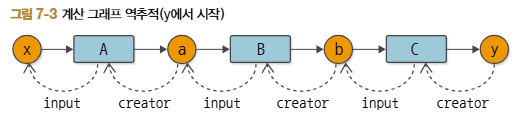   
- 그림과 같이 계산 그래프는 함수와 변수 사이의 연결로 구성됨
- 그리고 중요한 점은 이 '연결'이 실제로 계산을 수행하는 시점에(순전파로 데이터를 흘려보낼 때) 만들어진다는 것
- 이러한 특성에 이름을 붙인 것이 Define-by-Run
- 데이터를 흘려보냄으로써(Run함으로써) 연결이 규정된다는(Define된다는) 뜻   

또한 그림과 같이 노드들의 연결로 이루어진 데이터 구조를 '링크드 리스트(linked list)'라고 함   
노드는 그래프를 구성하는 요소이며, 링크(link)는 다른 노드를 가리키는 참조를 뜻함   
결국 '링크드 리스트'라는 데이터 구조를 이용해 계산 그래프를 표현하고 있는 것

## 7.2 역전파 도전

변수와 함수의 관계를 이용하여 역전파를 시도   
우선 y에서 b까지의 역전파를 시도해보면   
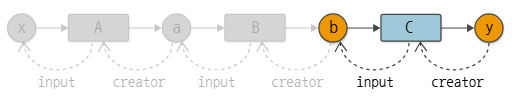   
이 부분은 다음과 같이 구현할 수 있음

In [32]:
y.grad = np.array(1.0)

C = y.creator  # 1. 함수를 가져옴
b = C.input  # 2. 함수의 입력을 가져옴
b.grad = C.backward(y.grad)  # 3. 함수의 backward 메서드를 호출

- y의 인스턴스 변수 creator에서 함수를 얻어오고, 그 함수의 input에서 입력 변수를 가져옴
- 그런 다음 함수의 backward 메서드를 호출   

이어서 변수 b에서 a로의 역전파를 보면   
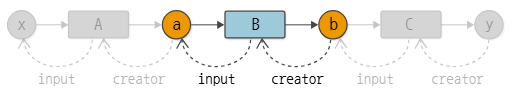   

In [33]:
B = b.creator  # 1. 함수를 가져옴
a = B.input  # 2. 함수의 입력을 가져옴
a.grad = B.backward(b.grad)  # 3. 함수의 backward 메서드를 호출

- 똑같은 흐름으로 진행됨   
- 구체적으로 다음과 같은 순서로 진행됨
    - 함수를 가져옴
    - 함수의 입력을 가져옴
    - 함수의 backward 메서드를 호출

마지막으로 변수 a에서 x로의 역전파까지 진행함

In [34]:
A = a.creator  # 1. 함수를 가져옴
x = A.input  # 2. 함수의 입력을 가져옴
x.grad = A.backward(a.grad)  # 3. 함수의 backward 메서드를 호출
print(x.grad)

3.297442541400256


- 이상으로 모든 역전파가 끝남

## 7.3 backward 메서드 추가

방금 역전파 코드에는 똑같은 처리 흐름이 반복해서 나타남   
변수에서 하나 앞의 변수로 거슬러 올라가는 로직이 그러했음   
그러므로 이 반복 작업을 자동화할 수 있도록 Variable 클래스에 backward라는 새로운 메서드를 추가하면

In [40]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

    def backward(self):
        f = self.creator  # 1. 함수를 가져옴
        if f is not None:
            x = f.input  # 2. 함수의 입력을 가져옴
            x.grad = f.backward(self.grad)  # 3. 함수의 backward 메서드를 호출
            x.backward()  # 하나 앞 변수의 backward 메서드를 호출(재귀)

- backward 메서드는 지금까지 반복한 처리 흐름과 거의 동일
- Variable의 creator에서 함수를 얻어오고, 그 함수의 입력 변수를 가져옴
- 그런 다음 함수의 backward 메서드를 호출
- 이런 식으로 각 변수의 backward 메서드가 재귀적으로 불리게 됨   

> Variable 인스턴스의 creator가 None이면 역전파가 중단됨   
> 창조자가 없으므로 이 Variable 인스턴스는 함수 바깥에서 생성됐음을 뜻함(높은 확률로 사용자가 만들어 건넨 변수일 것)   

이제 새로워진 Variable을 이용하여 역전파가 자동으로 실행되는 것을 살펴보면

In [41]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

# 역전파
y.grad = np.array(1.0)
y.backward()
print(x.grad)

3.297442541400256


- 이와 같이 변수 y의 backward 메서드를 호출하면 역전파가 자동으로 진행됨
- 실행 결과도 지금까지와 동일
- 방금 DeZero에서 가장 중요한 개념인 자동 미분의 기초를 완성함

# 8. 재귀에서 반복문으로

앞 단계에서는 Variable 클래스에 backward 메서드를 추가함   
이번에는 처리 효율을 개선하고 앞으로의 확장을 대비해 backward 메서드의 구현 방식을 바꿔봄

## 8.1 현재의 Variable 클래스

이전 장에서 구현한 Variable 클래스의 backward 메서드에서 눈에 밟히는 부분은 (입력 방향으로) 하나 앞 변수의 backward 메서드를 호출하는 코드   
'backward 메서드에서 backward 메서드를 호출하고, 호출된 backward 메서드에서 또 다른 backward 메서드를 호출하고, ...' 과정이 계속됨   
(창조자 함수가 없는 변수, 즉 self.creator가 None인 변수를 찾을 때까지 계속됨)   
이를 재귀 구조라고 함   

## 8.2 반복문을 이용한 구현

이번 절에서는 지금까지의 '재귀를 사용한 구현'을 '반복문을 이용한 구현'으로 고쳐봄   
코드는 다음과 같음

In [51]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

    def backward(self):
        funcs = [self.creator]
        while funcs:
            f = funcs.pop()  # 함수를 가져옴
            x, y = f.input, f.output  # 함수의 입력과 출력을 가져옴
            x.grad = f.backward(y.grad)  # backward 메서드를 호출

            if x.creator is not None:
                funcs.append(x.creator)  # 하나 앞의 함수를 리스트에 추가

- 이것이 반복문을 이용한 구현
- 주목할 점은 처리해야 할 함수들을 funcs라는 리스트에 차례로 집어넣는다는 것
- while 블록 안에서 funcs.pop()을 호출하여 처리할 함수 f를 꺼내고, f의 backward 메서드를 호출
- 이때 f.input과 f.output에서 함수 f의 입력과 출력 변수를 얻음으로써 f.backward()의 인수와 반환값을 올바르게 설정할 수 있음   

> 리스트의 pop 메서드는 리스트에서 마지막 원소를 꺼내줌(반환된 요소는 리스트에서 제거됨)   
> 예컨대 funcs = [1, 2, 3]일 때 x = funcs.pop()을 실행하면 3이 반환되고 funcs는 [1, 2]가 됨

## 8.3 동작 확인

개선된 Variable 클래스를 사용하여 실제로 미분을 해보기   
7단계에서와 똑같은 코드를 실행해보면

In [43]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

# 역전파
y.grad = np.array(1.0)
y.backward()
print(x.grad)

3.297442541400256


- 결과도 이전과 똑같음
- 이상으로 '재귀'에서 '반복문'으로 구현 방식을 전환했음
- 반복문 방식의 이점은 15단계에서 알 수 있음
- 15단계에서는 복잡한 계산 그래프를 다루는데, 방금 전환한 구현 덕분에 부드럽게 확장할 수 있음
- 처리 효율도 반복문 방식이 뛰어남   

> 재귀는 함수를 재귀적으로 호출할 때마다 중간 결과를 메모리에 유지하면서(스택에 쌓으면서) 처리를 이어감   
> 일반적으로 반복문 방식의 효율이 더 좋은 이유   
> 그러나 요즘 컴퓨터는 메모리가 넉넉한 편이라서 조금 더 사용하는 건 그리 문제가 되지 않음   
> 또한, '꼬리 재귀(tail recursion)' 기법을 이용하여 재귀를 반복문처럼 실행할 수 있는 경우도 있음   

이상으로 역전파 구현의 기반은 완성함   
앞으로는 더욱 복잡한 계산도 가능하도록 현재의 DeZero를 확장해나갈 것   
하지만 그 전에 다음 단계에서 DeZero의 '사용자 편의성'부터 개선함

# 9. 함수를 더 편리하게

DeZero가 역전파를 해낼 수 있게 되었음   
또한 Define-by-Run이라고 하는 전체 계산의 각 조각들을 런타임에 '연결'해내는 능력도 갖췄음   
하지만 사용하기에 조금 불편한 부분이 있어서 이번 단계에서는 DeZero의 함수에 세 가지 개선을 추가함

## 9.1 파이썬 함수로 이용하기

지금까지의 DeZero는 함수를 '파이썬 클래스'로 정의해 사용했음   
그래서 가령 Square 클래스를 사용하는 계산을 하려면 코드를 다음처럼 작성해야 했음

In [44]:
x = Variable(np.array(0.5))
f = Square()
y = f(x)

- 이와 같이 Square 클래스이 인스턴스를 생성한 다음, 이어서 그 인스턴스를 호출하는 두 단계로 구분해 진행해야 함
- 사용자 입장에서는 조금 번거로움
- y = Square()(x) 형태로 한 줄로 적을 수도 있지만 모양새가 좋지 않음
- 더 바람직한 해법은 '파이썬 함수'를 지원하는 것   

그래서 다음 코드를 추가함

In [46]:
def square(x):
    f = Square()
    return f(x)

def exp(x):
    f = Exp()
    return f(x)

- 보다시피 square와 exp라는 두 가지 파이썬 함수를 구현했음
- 이로써 'DeZero 함수'를 '파이썬 함수'로 이용할 수 있게 됨   

참고로 위 코드는 다음과 같이 한 줄로 표현할 수도 있음

In [48]:
def square(x):
    return Square()(x)

def exp(x):
    return Exp()(x)

- 이전의 f = Square() 형태에서는 DeZero 함수를 f라는 변수 이름으로 참조한 데 반해, 간소화한 코드에서는 직접 Square()(x)라고 쓴 것   

그럼 방금 구현한 두 함수를 사용해보면

In [49]:
x = Variable(np.array(0.5))
a = square(x)
b = exp(a)
y = square(b)

y.grad = np.array(1.0)
y.backward()
print(x.grad)

3.297442541400256


- 보다시피 최초의 np.array(0.5)를 Variable로 감싸면 일반적인 수치 계산을 하듯, 즉 넘파이를 사용해 계산하도록 코딩할 수 있음   

또한 다음과 같이 함수를 연속으로 적용할 수 있음

In [50]:
x = Variable(np.array(0.5))
y = square(exp(square(x)))  # 연속으로 적용
y.grad = np.array(1.0)
y.backward()
print(x.grad)

3.297442541400256


이제 계산을 더 자연스러운 코드로 표현할 수 있게 되었음   
이것이 첫 번째 개선

## 9.2 backward 메서드 간소화

두 번째 개선은 역전파 시 사용자의 번거로움을 줄이기 위한 것   
구체적으로는 방금 작성한 코드에서 y.grad = np.array(1.0) 부분을 생략하려 함   
지금까지는 역전파할 때마다 y.grad = np.array(1.0)이라는 코드를 작성해야 했음   
이 코드를 생략할 수 있도록 Variable의 backward 메서드에 다음 두 줄을 추가

In [52]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

    def backward(self):
        if self.grad is None:
            self.grad = np.ones_like(self.data)

        funcs = [self.creator]
        while funcs:
            f = funcs.pop()  # 함수를 가져옴
            x, y = f.input, f.output  # 함수의 입력과 출력을 가져옴
            x.grad = f.backward(y.grad)  # backward 메서드를 호출

            if x.creator is not None:
                funcs.append(x.creator)  # 하나 앞의 함수를 리스트에 추가

- 이와 같이 만약 변수의 grad가 None이면 자동으로 미분값을 생성함
- np.ones_like(self, data) 코드는 self.data의 형상과 데이터 타입이 같은 ndarray 인스턴스를 생성하는데, 모든 요소를 1로 채워서 돌려줌
- self.data가 스칼라이면 self.grad도 스칼라가 됨   

> 이전까지는 출력의 미분값을 np.array(1.0)으로 사용했지만, 방금 코드에서는 np.ones_like()를 썼음   
> 그 이유는 Variable의 data와 grad의 데이터 타입을 같게 만들기 위해서   
> 예를 들어 data의 타입이 32비트 부동소수점 숫자면 grad의 타입도 32비트 부동소수점 숫자가 됨   
> 참고로, np.array(1.0)은 64비트 부동소수점 숫자 타입으로 만들어줌   

이제 어떤 계산을 하고 난 뒤의 최종 출력 변수에서 backward 메서드를 호출하는 것만으로 미분값이 구해짐

In [53]:
x = Variable(np.array(0.5))
y = square(exp(square(x)))
y.backward()
print(x.grad)

3.297442541400256


## 9.3 ndarray만 취급하기

DeZero의 Variable은 데이터로 ndarray 인스턴스만 취급하게끔 의도했음   
하지만 사용하는 사람이 모르고 float이나 int 같은 의도치 않은 데이터 타입을 사용하는 일도 충분히 일어날 수 있음   
예컨대 Variable(1.0) 혹은 Variable(3) 처럼 사용할 수도 있음   
이런 사태를 막기 위해 Variable이 ndarray 인스턴스만을 담는 '상자'가 되도록 하기 위해   
그래서 Variable에 ndarray 인스턴스 외의 데이터를 넣을 경우 즉시 오류를 일으키기로 함(미분값은 None으로 유지)   
이렇게 하면 문제를 조기에 발견할 수 있음   

우선 Variable 클래스의 초기화 부분에 다음 코드를 추가함

In [54]:
class Variable:
    def __init__(self, data):
        if data is not None:
            if not isinstance(data, np.ndarray):
                raise TypeError('{}은(는) 지원하지 않습니다.'.format(type(data)))
            
        self.data = data
        self.grad = None
        self.creator = None

    def set_creator(self, func):
        self.creator = func

    def backward(self):
        if self.grad is None:
            self.grad = np.ones_like(self.data)

        funcs = [self.creator]
        while funcs:
            f = funcs.pop()  # 함수를 가져옴
            x, y = f.input, f.output  # 함수의 입력과 출력을 가져옴
            x.grad = f.backward(y.grad)  # backward 메서드를 호출

            if x.creator is not None:
                funcs.append(x.creator)  # 하나 앞의 함수를 리스트에 추가

- 이와 같이 인수로 주어진 data가 None이 아니고 ndarray 인스턴스도 아니라면 TypeError라는 예외를 발생시킴   
- 이때 오류 메시지로 출력할 문장도 준비

In [59]:
x = Variable(np.array(1.0))
x = Variable(None)

# x = Variable(1.0)  # <class 'float'>은(는) 지원하지 않습니다.

- 보는 바와 같이 ndarray나 None이면 아무 문제가 없지만, 다른 데이터 타입을 입력하면(위 예에서는 float) 예외가 발생함
- 덕분에 잘못된 데이터 타입을 사용했음을 즉시 알 수 있음   

그런데 이렇게 바꾸면 주의할 게 하나 생김 - 넘파이의 독특한 관례 때문   

In [60]:
x = np.array([1.0])
y = x ** 2
print(type(x), x.ndim)
print(type(y))

<class 'numpy.ndarray'> 1
<class 'numpy.ndarray'>


- 여기서 x는 1차원 ndarray
- 여기에 제곱(x ** 2)을 하면 y의 데이터 타입도 ndarray가 됨 - 예상대로의 결과   

문제가 되는 것은 다음 경우

In [61]:
x = np.array(1.0)  # 0차원 ndarray
y = x ** 2
print(type(x), x.ndim)
print(type(y))

<class 'numpy.ndarray'> 0
<class 'numpy.float64'>


- 여기서 x는 0차원의 ndarray인데, 제곱(x ** 2)을 하면 np.float64가 되어버림
- 이상해 보일지 모르지만 넘파이가 의도한 동작
- 즉, 0차원 ndarray 인스턴스를 사용하여 계산하면 결과의 데이터 타입이 numpy.float64나 numpy.float32 등으로 달라짐
- 다시 말해 DeZero 함수의 계산 결과(출력)도 numpy.float64나 numpy.float32가 되는 경우가 나옴
- 그러나 Variable은 데이터가 항상 ndarray 인스턴스라고 가정하고 있으니 대처를 해줘야 함   

이를 위해 우선 다음과 같은 편의 함수를 준비함

In [62]:
def as_array(x):
    if np.isscalar(x):
        return np.array(x)
    return x

- 여기에 쓰인 np.isscalar는 입력 데이터가 numpy.float64 같은 스칼라 타입인지 확인해주는 함수(파이썬의 int와 float 타입도 스칼라로 판단함)   

np.isscalar 함수를 사용하는 예시를 보면

In [63]:
import numpy as np
print(np.isscalar(np.float64(1.0)))
print(np.isscalar(2.0))
print(np.isscalar(np.array(1.0)))
print(np.isscalar(np.array([1, 2, 3])))

True
True
False
False


- 이처럼 x가 스칼라 타입인지 쉽게 확인할 수 있으며, as_array 함수는 이를 이용하여 입력이 스칼라인 경우 ndarray 인스턴스로 변환해줌   

이제 as_array라는 편의 함수가 준비되었으니 Function 클래스에 다음 코드를 추가

In [64]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(as_array(y))
        output.set_creator(self)  # 출력 변수에 창조자를 설정
        self.input = input
        self.output = output  # 출력도 저장
        return output

    def forward(self, x):
        raise NotImplementedError()

    def backward(self, x):
        raise NotImplementedError()

- 이와 같이 순전파의 결과인 y를 Variable로 감쌀 때 as_array()를 이용함
- 이렇게 하여 출력 결과인 output은 항상 ndarray 인스턴스가 되도록 보장하는 것
- 이제 0차원 ndarray 인스턴스를 사용한 계산에서도 모든 데이터는 ndarray 인스턴스이니 안심해도 됨   

# 10. 테스트

소프트웨어 개발에서는 테스트를 뺴놓을 수 없음   
테스트를 해야 실수(버그)를 예방할 수 있으며 테스트를 자동화해야 소프트웨어의 품질을 유지할 수 있음   
DeZero도 마찬가지   
그래서 이번 단계에서는 테스트 방법, 특히 딥러닝 프레임워크의 테스트 방법에 대해 설명함   

> 소프트웨어 테스트는 규모가 커지면 독특한 규약이나 세세한 규칙이 많아지기 쉬움   
> 그렇다고 테스트를 처음부터 어렵게 생각할 필요는 없음   
> 우선 '테스트한다'는 그 자체가 중요
> 이번 단계에서는 본격적인 테스트가 아니라 가능한 한 간단한 테스트를 해봄

## 10.1 파이썬 단위 테스트

파이썬으로 테스트할 때는 표준 라이브러리에 포함된 unittest를 사용하면 편함   
여기에서는 이전 단계에서 구현한 square 함수를 테스트해봄

In [65]:
import unittest

class SquareTest(unittest.TestCase):
    def test_forward(self):
        x = Variable(np.array(2.0))
        y = square(x)
        expected = np.array(4.0)
        self.assertEqual(y.data, expected)

- 이와 같이 우선 unittest를 임포트하고 unittest.TestCase를 상속한 SquareTest 클래스를 구현
- 여기서 기억할 규칙이 있음
- 테스트할 때는 이름이 test로 시작하는 메서드를 만들고 그 안에 테스트할 내용을 적음
- 앞의 테스트는 square 함수의 출력이 기댓값(expected)과 같은지 확인
- 정확하게는 입력이 2.0일 때 출력이 4.0이 맞는지 확인함   

> 앞의 예에서 square 함수의 출력이 기댓값과 같은지 확인하지 위해 self.assertEqual이라는 메서드를 사용했음   
> 이 메서드는 주어진 두 객체가 동일한지 여부를 판정함   
> 이 메서드 외에도 self.assertGreater와 self.assertTrue 등 unittest에는 다양한 메서드가 준비되어 있음   

이제 테스트를 실행   
앞의 테스트 코드가 steps/step10.py 파일에 있다고 가정했을 때 터미널에서 다음 명령을 실행하면 됨   
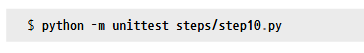   
- python 명령을 실행할 때 앞의 예처럼 -m unittest 인수를 제공하면 파이썬 파일을 테스트 모드로 실행할 수 있음
- 혹은 step10.py 파일 끝에 다음 코드를 추가하면 평소처럼 python steps/step10.py만 입력해도 테스트를 수행할 수 있음   

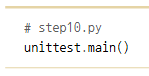   
테스트가 뭐라고 출력했는지 확인할 차례   
실제로 앞의 명령을 실행하면 다음 결과가 출력됨   
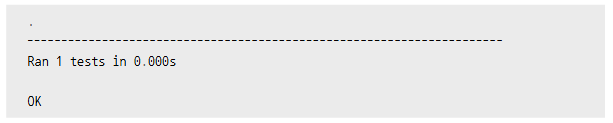   
- '1개의 테스트를 실행했고, 결과는 OK다'라는 뜻
- 즉, 테스트를 통과한 것
- 만약 무언가 문제가 있다면 'FAIL:test_forward (step10.SquareTest)' 같은 문장이 출력되어 테스트가 실패했음을 알려줄 것

## 10.2 square 함수의 역전파 테스트

이어서 square 함수의 역전파도 테스트   
방금 구현한 SquareTest 클래스에 다음 코드를 추가

In [67]:
class SquareTest(unittest.TestCase):
    def test_forward(self):
        x = Variable(np.array(2.0))
        y = square(x)
        expected = np.array(4.0)
        self.assertEqual(y.data, expected)

    def test_backward(self):
        x = Variable(np.array(3.0))
        y = square(x)
        y.backward()
        expected = np.array(6.0)
        self.assertEqual(x.grad, expected)

- test_backward 메서드를 추가함
- 메서드 안에서 y.backward()로 미분값을 구하고, 그 값이 기댓값과 일치하는지 확인
- 참고로 여기에서 설정한 기댓값 6.0은 손으로 계산해서 구한 값을 하드코딩한 것   

그럼 다시 테스트를 돌려보면   
결과는 다음과 같음   
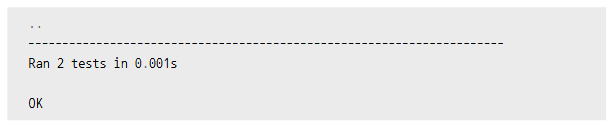   
- 결과를 보면 2개의 테스트를 통과했음을 알 수 있음
- 원한다면 지금까지와 같은 요령으로 다른 테스트 케이스(입력과 기댓값)도 추가해나갈 수 있음
- 테스트 케이스가 많아질수록 square 함수의 신뢰도도 높아질 것
- 그리고 코드를 수정할 때마다 즉시즉시 테스트를 실행해주면 square 함수의 상태를 반복해서 확인할 수 있음

## 10.3 기울기 확인을 이용한 자동 테스트

앞 절에서 역전파 테스트를 작성하며 미분의 기댓값을 손으로 계산해 입력했음   
이 부분을 자동화할 방법이 있음 - **기울기 확인(gradient checking)** 이라는 방법   
기울기 확인이란 수치 미분으로 구한 결과와 역전파로 구한 결과를 비교하여 그 차이가 크면 역전파 구현에 문제가 있다고 판단하는 검증 기법   

> 책에선 4단계에서 수치 미분을 구현했음   
> 수치 미분은 쉽게 구현할 수 있고 거의 정확한 미분값을 내어줌   
> 따라서 수치 미분의 결과와 비교하면 역전파를 정확히 구현했는지 검증할 수 있음   

기울기 확인은 (기댓값을 몰라도) 입력값만 준비하면 되므로 테스트 효율을 높여줌   
그러니 여기 테스트에서도 기울기 확인을 이용함   
4단계에서 구현한 numerical_diff 함수를 사용하면 됨   
복습도 겸해서 이 함수의 코드도 함께 보면

In [68]:
def numerical_diff(f, x, eps=1e-4):
    x0 = Variable(x.data - eps)
    x1 = Variable(x.data + eps)
    y0 = f(x0)
    y1 = f(y1)
    return (y1.data - y0.data) / (2 * eps)

class SquareTest(unittest.TestCase):
    def test_forward(self):
        x = Variable(np.array(2.0))
        y = square(x)
        expected = np.array(4.0)
        self.assertEqual(y.data, expected)

    def test_backward(self):
        x = Variable(np.array(3.0))
        y = square(x)
        y.backward()
        expected = np.array(6.0)
        self.assertEqual(x.grad, expected)

    def test_gradient_check(self):
        x = Variable(np.random.rand(1))  # 무작위 입력값 생성
        y = square(x)
        y.backward()
        num_grad = numerical_diff(square, x)
        flg = np.allclose(x.grad, num_grad)
        self.assertTrue(flg)

- 기울기 확인을 할 test_gradient_check 메서드 안에서 무작위 입력값을 하나 생성
- 이어서 역전파로 미분값을 구하고, numerical_diff 함수를 사용해서 수치 미분으로도 계산
- 그런 다음 두 메서드로 각각 구한 값들이 거의 일치하는지 확인
- 이때 np.allclose라는 넘파이 함수를 이용
    - np.allclose(a, b)는 ndarray 인스턴스인 a와 b의 값이 가까운지(close) 판정함
    -얼마나 가까워야 가까운 것인지는 np.allclose(a, b, rtol=1e-05, atol=1e-08)과 같이 rtol과 atol로 지정할 수 있음
    - 이 함수는 a와 b으 모든 요소가 다음 조건을 만족하면 True를 반환함   
    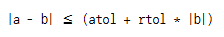   
    - 한편 기울기 확인을 하는 대상의 계산(함수)에 따라 atol과 rtol의 값을 미세하게 조정해야 할 수도 있음   

그럼 이상의 기울기 확인을 코드에 추가하고 테스트를 돌려보면   
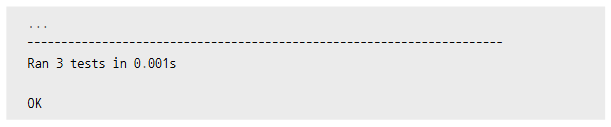   
이와 같이 기울기 확인을 이용하면 미분을 자동으로 계산하는 딥러닝 프레임워크를 반자동으로 테스트할 수 있고,   
덕분에 더 체계적으로 더 넓은 범위를 검증하는 테스트 케이스를 만들 수 있음

## 10.4 테스트 정리

DeZero 개발에 한정한다면 테스트에 관한 지식은 이 정도면 충분   
여기서 배운 것만으로도 DeZero 테스트 코드를 작성하는 데 아무런 문제가 없음   
다만 앞으로 이 책에서는 테스트에 대한 직접적인 설명은 생략하고 진행함   

또한 테스트 파일들은 하나의 장소에 모아 관리하는 것이 일반적   
이 책에서도 테스트 코드는 tests 디렉터리에 모아둠(테스트용 편의 기능도 추가로 구현되어 있음)   

테스트 파일들은 다음 명령으로 한꺼번에 실행할 수 있음   
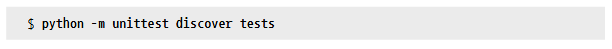   
이와 같이 discover라는 하위 명령을 사용하면 discover 다음에 지정한 디렉터리에서 테스트 파일이 있는지 검색함   
그리고 발견한 모든 파일을 실행하는 것   
기본적으로는 지정한 디렉터리에서 이름이 test.py 형태인 파일을 테스트 파일로 인식함(변경할 수 있음)   
이것으로 tests 디렉터리에 들어 있는 모든 테스트를 한 번에 실행할 수 있음   

> DeZero의 tests 디렉터리에는 정답을 체이너에게 묻는 테스트도 있음   
> 예를 들어 시그모이드 함수를 테스트하는 경우 동일한 입력으로 DeZero와 Chainer 각각에 계산을 시키고 출력값이 거의 같은지 비교함   

또한 DeZero의 깃허브 저장소는 트래비스 CI라는 지속적 통합(continuous integration)(CI) 서비스와 연계해둠   
DeZero의 깃허브 저장소에서 코드를 푸시(push)하고, 풀 리퀘스트(pull request)를 병합하고, 매시간 자동으로 테스트가 실행되도록 설정해놓은 것   
테스트 결과에 문제가 있으면 메일 등으로 보고됨   
게다가 DeZero 깃허브 저장소의 첫 화면에는 아래 그림과 같이 로고 하단 왼쪽에 빌드 상태가 표시되게 해둠   
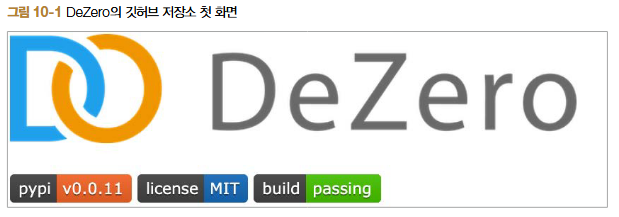   
'build : passing'은 빌드 후 테스트까지 통과했다는 표시(테스트에 실패하면 'build : failed'라는 배지가 표시됨)   
이처럼 CI 도구와 연계하면 소스 코드를 지속해서 테스트할 수 있음 - 코드의 신뢰성을 유지하는 요령   

지금의 DeZero는 작은 소프트웨어지만 앞으로 더 큰 소프트웨어로 성장시킬 것   
여기에서 설명한 테스트 방식을 도입하면 성장 과정에서도 코드의 신뢰성을 꾸준히 유지할 수 있을 것   

1고지의 내용은 끝   
여기까지 조금씩 그리고 꾸준히 DeZero를 만들어왔음   
'작은 상자(변수)'밖에 없는 모습으로 탄생했지만 지금은 역전파라는 복잡한 알고리즘도 수행할 만큼 성장했음   
그러나 현재의 역전파 구현은 간단한 계산 밖에 처리하지 못함   
그래서 다음 고지에서는 더 복잡한 계산에도 적용할 수 있도록 DeZero를 확장해봄